In [1]:
import math
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sumolib
import contextily as cx
import geopandas 
import lib.dataGenLib as dg
import json
import rtree

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# df = pd.read_csv('/home/ctm/Documents/ML/MLTest/symaps_data_analyze/dataset1/training/training_0_150_20251112_23:52:30.csv')
df = pd.read_csv("/home/ctm/Documents/ML/MLTest/symaps_data_analyze/preprocess/dataset10/training/training_20252810_18:32:01.csv")

In [4]:
# load sumo net xml
net = sumolib.net.readNet("./dataset1/map/site1_new.net.xml")

In [5]:
df.head(1)

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y,edge,ts,departure,destination
0,220,1.607521e+12,5.418094,2.576576,-0.589794,3.298336,1.418282,5.11065,-5.511428,1.593727,0.095754,20.656905,VEHICLE,4.464588,-4.007735,1151278800#2,0,1151278800#2,1090414507


In [10]:
df[['Id','timestamp']]

,Id,timestamp
0,220,1.607521e+12
1,220,1.607521e+12
2,220,1.607521e+12
3,220,1.607521e+12
4,220,1.607521e+12
...,...,...
2926245,16921588,1.607516e+12
2926246,16921588,1.607516e+12
2926247,16921588,1.607516e+12
2926248,16921588,1.607516e+12


In [18]:
# get sumo Geo projection reference
p = net.getGeoProj()
p.crs 

<Projected CRS: +proj=utm +zone=31 +ellps=WGS84 +datum=WGS84 +unit ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [19]:
# get sumo information
lat,lon,head = dg.rsu_info("rsu1.json")

# get rsu projected geoposition 
x, y = p(lon,lat)

In [20]:
v_rx = df.loc[:,"rot_x"]+x
v_ry = df.loc[:,"rot_y"]+y

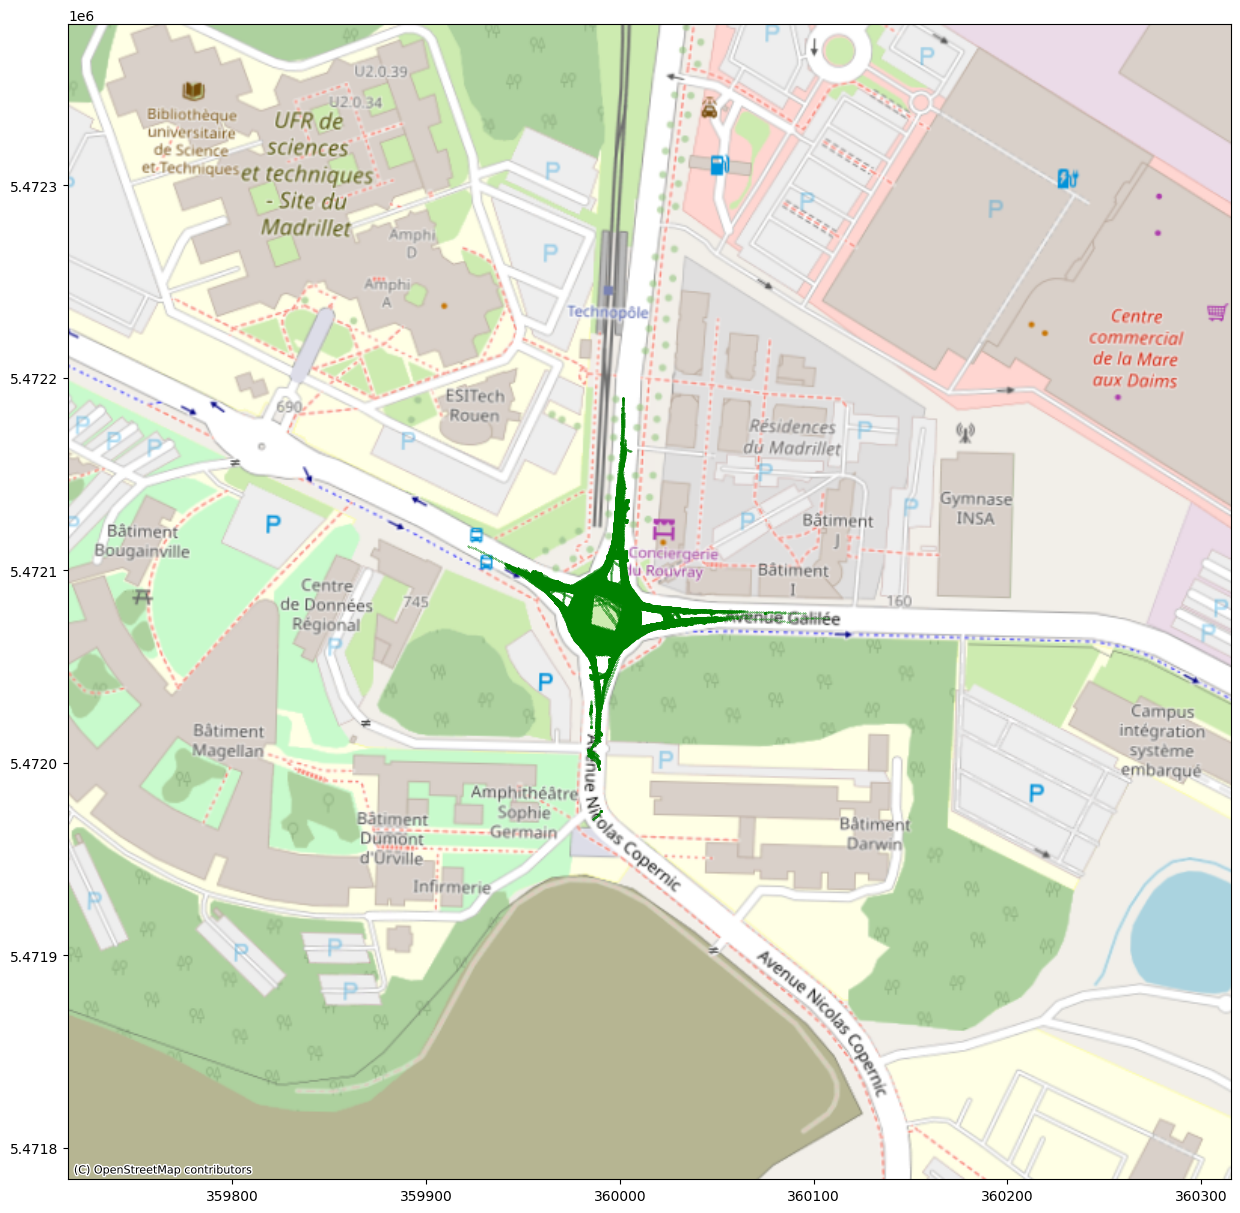

In [21]:
fig,ax = plt.subplots(figsize=(15,15))
ax.scatter(v_rx,v_ry,s=0.1,c='g')
ax.set_xlim([x-300,x+300])
ax.set_ylim([y-300,y+300])

cx.add_basemap(
    ax,
    crs= p.crs,
    source=cx.providers.OpenStreetMap.Mapnik
)

In [10]:
df[10:20].copy().reset_index().reindex(range(20)).ffill()

,index,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y,edge,ts,departure,destination
0,10.0,220.0,1.607521e+12,0.229691,3.452641,-0.675555,3.215097,1.393110,4.986432,-5.379338,1.042742,0.092184,19.728881,VEHICLE,-0.759192,-3.375962,1151278800#2,10.0,1151278800#2,1090414507
1,11.0,220.0,1.607521e+12,-0.476479,3.565515,-0.571155,3.215097,1.393110,4.986432,-5.633181,1.060659,0.237349,20.659446,VEHICLE,-1.468372,-3.283872,1151278800#2,11.0,1151278800#2,1090414507
2,12.0,220.0,1.607521e+12,-1.182649,3.678389,-0.466755,3.196007,1.382902,4.937426,-5.887025,1.078577,0.382514,21.590010,VEHICLE,-2.177553,-3.191782,1151278800#2,12.0,1151278800#2,1090414507
3,13.0,220.0,1.607521e+12,-1.915709,3.795807,-0.364266,3.196007,1.382902,4.937426,-6.119884,1.094930,0.488666,22.452851,VEHICLE,-2.913806,-3.096421,1151278800#2,13.0,1151278800#2,1090414507
4,14.0,220.0,1.607521e+12,-2.648769,3.913224,-0.261777,3.176218,1.371667,4.888758,-6.352743,1.111283,0.594818,23.315692,VEHICLE,-3.650060,-3.001059,1151278800#2,14.0,1151278800#2,1090414507
5,15.0,220.0,1.607521e+12,-3.427923,3.990993,-0.158998,3.176218,1.371667,4.888758,-6.586911,1.078178,0.675149,24.153274,VEHICLE,-4.419267,-2.854603,1151278800#2,15.0,1151278800#2,1090414507
6,16.0,220.0,1.607521e+12,-4.207077,4.068762,-0.056219,3.158570,1.359778,4.840650,-6.821078,1.045073,0.755481,24.990856,VEHICLE,-5.188474,-2.708146,1151278800#2,16.0,1151278800#2,1090414507
7,17.0,220.0,1.607521e+12,-5.188747,3.874974,0.071450,3.158570,1.359778,4.840650,-7.222937,0.749389,0.847018,26.347742,VEHICLE,-6.074842,-2.243839,1151278800#2,17.0,1151278800#2,1090414507
8,18.0,220.0,1.607521e+12,-6.170417,3.681186,0.199119,3.138113,1.355385,4.829612,-7.624796,0.453705,0.938556,27.704627,VEHICLE,-6.961210,-1.779531,1090414505,18.0,1151278800#2,1090414507
9,19.0,220.0,1.607521e+12,-6.914459,3.385456,0.139086,3.138113,1.355385,4.829612,-7.663305,0.054444,0.805818,27.943312,VEHICLE,-7.590793,-1.284879,1090414505,19.0,1151278800#2,1090414507


In [11]:
df.loc[0:10,'PositionX']

KeyError: 'PositionX'